In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
warnings.filterwarnings('ignore')

In [7]:
# Install CatBoost Model #
try:
    from catboost import CatBoostClassifier
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'catboost'])
    from catboost import CatBoostClassifier

In [8]:
# Data Loading #
train_df = pd.read_csv('/content/sample_data/train.csv')
val_df   = pd.read_csv('/content/sample_data/val.csv')
test_df  = pd.read_csv('/content/sample_data/test.csv')

In [10]:
# Feature Engineering #
def check_win(board, player):
    # Horizontal
    for r in range(6):
        for c in range(4):
            if np.all(board[r, c:c+4] == player):
                return True
    # Vertical
    for c in range(7):
        for r in range(3):
            if np.all(board[r:r+4, c] == player):
                return True
    # Diagonal down-right
    for r in range(3):
        for c in range(4):
            if all(board[r+i, c+i] == player for i in range(4)):
                return True
    # Diagonal down-left
    for r in range(3):
        for c in range(3, 7):
            if all(board[r+i, c-i] == player for i in range(4)):
                return True
    return False

def simulate_drop_and_get(board_state, col_idx, player):
    b = board_state.copy()
    for r in range(6):
        if b[r, col_idx] == 0:
            b[r, col_idx] = player
            return b
    return None

def count_winning_moves(board_state, player):
    cnt = 0
    for c in range(7):
        newb = simulate_drop_and_get(board_state, c, player)
        if newb is not None and check_win(newb, player):
            cnt += 1
    return cnt

def window_score_board(board_state):
    score = 0.0
    # Horizontal
    for r in range(6):
        for c in range(4):
            window = board_state[r, c:c+4]
            score += (window==1).sum()*2.0 - (window==-1).sum()*2.0
    # Vertical
    for c in range(7):
        for r in range(3):
            window = board_state[r:r+4, c]
            score += (window==1).sum()*2.0 - (window==-1).sum()*2.0
    # Diagonals
    for r in range(3):
        for c in range(4):
            window = np.array([board_state[r+i, c+i] for i in range(4)])
            score += (window==1).sum()*2.5 - (window==-1).sum()*2.5
    for r in range(3):
        for c in range(3,7):
            window = np.array([board_state[r+i, c-i] for i in range(4)])
            score += (window==1).sum()*2.5 - (window==-1).sum()*2.5
    return score

def engineer_features(df):
    board_cols = [f'p{i}' for i in range(1, 43)]
    board = df[board_cols].values
    board_3d = board.reshape(-1, 6, 7)

    features = {}
    n = len(df)

    # Original board positions and turn
    for col in board_cols:
        features[col] = df[col].values
    features['turn'] = df['turn'].values

    # Column heights & availability
    for col_idx in range(7):
        column = board_3d[:, :, col_idx]
        heights = (column != 0).sum(axis=1)
        features[f'col_{col_idx}_height'] = heights
        available = (column[:, -1] == 0).astype(int)
        features[f'col_{col_idx}_available'] = available

    # Piece counts
    current_player_pieces = (board == 1).sum(axis=1)
    opponent_pieces = (board == -1).sum(axis=1)
    features['current_player_count'] = current_player_pieces
    features['opponent_count'] = opponent_pieces
    features['piece_difference'] = current_player_pieces - opponent_pieces

    # Center control
    center_col = board_3d[:, :, 3]
    features['center_current_player'] = (center_col == 1).sum(axis=1)
    features['center_opponent'] = (center_col == -1).sum(axis=1)

    # Horizontal & Vertical threats
    threats_current = np.zeros(n)
    threats_opponent = np.zeros(n)
    for i in range(n):
        board_state = board_3d[i]
        for row in range(6):
            for col in range(4):
                window = board_state[row, col:col+4]
                if (window == 1).sum() == 3 and (window == 0).sum() == 1:
                    threats_current[i] += 1
                if (window == -1).sum() == 3 and (window == 0).sum() == 1:
                    threats_opponent[i] += 1
        for col in range(7):
            for row in range(3):
                window = board_state[row:row+4, col]
                if (window == 1).sum() == 3 and (window == 0).sum() == 1:
                    threats_current[i] += 1
                if (window == -1).sum() == 3 and (window == 0).sum() == 1:
                    threats_opponent[i] += 1

    features['threats_current_player'] = threats_current
    features['threats_opponent'] = threats_opponent

    # Diagonal threats
    diag_threats_current = np.zeros(n)
    diag_threats_opponent = np.zeros(n)
    for i in range(n):
        board_state = board_3d[i]
        for row in range(3):
            for col in range(4):
                window = [board_state[row+j, col+j] for j in range(4)]
                if window.count(1) == 3 and window.count(0) == 1:
                    diag_threats_current[i] += 1
                if window.count(-1) == 3 and window.count(0) == 1:
                    diag_threats_opponent[i] += 1
        for row in range(3):
            for col in range(3, 7):
                window = [board_state[row+j, col-j] for j in range(4)]
                if window.count(1) == 3 and window.count(0) == 1:
                    diag_threats_current[i] += 1
                if window.count(-1) == 3 and window.count(0) == 1:
                    diag_threats_opponent[i] += 1

    features['diag_threats_current'] = diag_threats_current
    features['diag_threats_opponent'] = diag_threats_opponent

    # Two-in-a-row patterns
    two_in_row_current = np.zeros(n)
    two_in_row_opponent = np.zeros(n)
    for i in range(n):
        board_state = board_3d[i]
        for row in range(6):
            for col in range(6):
                if board_state[row, col] == board_state[row, col+1] != 0:
                    if board_state[row, col] == 1:
                        two_in_row_current[i] += 1
                    else:
                        two_in_row_opponent[i] += 1
        for col in range(7):
            for row in range(5):
                if board_state[row, col] == board_state[row+1, col] != 0:
                    if board_state[row, col] == 1:
                        two_in_row_current[i] += 1
                    else:
                        two_in_row_opponent[i] += 1

    features['two_in_row_current'] = two_in_row_current
    features['two_in_row_opponent'] = two_in_row_opponent

    # Edge control & bottom row
    left_edge = board_3d[:, :, 0]
    right_edge = board_3d[:, :, 6]
    features['left_edge_current'] = (left_edge == 1).sum(axis=1)
    features['left_edge_opponent'] = (left_edge == -1).sum(axis=1)
    features['right_edge_current'] = (right_edge == 1).sum(axis=1)
    features['right_edge_opponent'] = (right_edge == -1).sum(axis=1)
    bottom_row = board_3d[:, 0, :]
    features['bottom_current'] = (bottom_row == 1).sum(axis=1)
    features['bottom_opponent'] = (bottom_row == -1).sum(axis=1)

    # Board fill ratio
    features['board_fill'] = (board != 0).sum(axis=1) / 42.0

    # Empty spaces per row
    for row_idx in range(6):
        row = board_3d[:, row_idx, :]
        features[f'row_{row_idx}_empty'] = (row == 0).sum(axis=1)

    # Strategic features: immediate wins, double threats
    for col_idx in range(7):
        features[f'col_{col_idx}_immediate_win'] = np.zeros(n, dtype=int)
        features[f'col_{col_idx}_opponent_immediate_win'] = np.zeros(n, dtype=int)
        features[f'col_{col_idx}_double_threat'] = np.zeros(n, dtype=int)

    features['any_immediate_win'] = np.zeros(n, dtype=int)
    features['any_opponent_immediate_win'] = np.zeros(n, dtype=int)
    features['num_current_winning_moves'] = np.zeros(n, dtype=int)
    features['num_opponent_winning_moves'] = np.zeros(n, dtype=int)
    features['num_double_threats'] = np.zeros(n, dtype=int)
    features['window_score'] = np.zeros(n, dtype=float)
    features['column_preference_score'] = np.zeros(n, dtype=float)

    col_weights = np.array([3 - abs(c - 3) for c in range(7)])

    for i in range(n):
        board_state = board_3d[i]
        features['window_score'][i] = window_score_board(board_state)

        double_threat_count = 0
        any_im_win = 0
        any_opp_im_win = 0
        col_pref_score = 0.0

        for c in range(7):
            newb_cur = simulate_drop_and_get(board_state, c, 1)
            if newb_cur is not None:
                if check_win(newb_cur, 1):
                    features[f'col_{c}_immediate_win'][i] = 1
                    any_im_win = 1
                wins_after = count_winning_moves(newb_cur, 1)
                if wins_after >= 2:
                    features[f'col_{c}_double_threat'][i] = 1
                    double_threat_count += 1

            newb_opp = simulate_drop_and_get(board_state, c, -1)
            if newb_opp is not None:
                if check_win(newb_opp, -1):
                    features[f'col_{c}_opponent_immediate_win'][i] = 1
                    any_opp_im_win = 1

            col_pref_score += col_weights[c] * (board_state[:, c] == 1).sum()

        features['num_current_winning_moves'][i] = count_winning_moves(board_state, 1)
        features['num_opponent_winning_moves'][i] = count_winning_moves(board_state, -1)
        features['any_immediate_win'][i] = any_im_win
        features['any_opponent_immediate_win'][i] = any_opp_im_win
        features['num_double_threats'][i] = double_threat_count
        features['column_preference_score'][i] = col_pref_score

    return pd.DataFrame(features)

#  Apply features #

X_train = engineer_features(train_df)
y_train = train_df['label_move_col'].values

X_val = engineer_features(val_df)
y_val = val_df['label_move_col'].values

X_test = engineer_features(test_df)

In [17]:
# Hyperparameters Tuning #
param_distributions = {
    'iterations': [500, 800],
    'learning_rate': [0.03, 0.05],
    'depth': [6, 8],
    'l2_leaf_reg': [3, 5]
}

base_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0,
    task_type='GPU'
)

random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("Best Params:", best_params)


Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 800, 'depth': 8}


In [18]:
# Model Training - CatBoost #
cat_model = CatBoostClassifier(
    **best_params,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0,
    early_stopping_rounds=100
)

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)

Validation Accuracy: 0.7115
              precision    recall  f1-score   support

       Col_0     0.6014    0.5172    0.5562      1450
       Col_1     0.7837    0.5914    0.6741       925
       Col_2     0.7763    0.6583    0.7124      1033
       Col_3     0.7226    0.9378    0.8163      3958
       Col_4     0.7746    0.6621    0.7140      1033
       Col_5     0.7921    0.5849    0.6729       925
       Col_6     0.6016    0.5186    0.5570      1450

    accuracy                         0.7115     10774
   macro avg     0.7218    0.6386    0.6718     10774
weighted avg     0.7114    0.7115    0.7021     10774



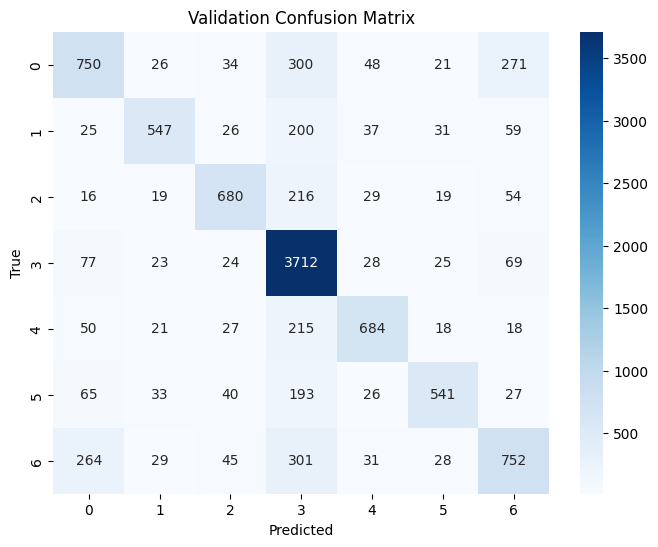

In [19]:
# Model Evaluation and Visualization #
val_pred = cat_model.predict(X_val).reshape(-1).astype(int)
val_acc = accuracy_score(y_val, val_pred)
cm = confusion_matrix(y_val, val_pred)

print(f"Validation Accuracy: {val_acc:.4f}")

print(classification_report(
    y_val, val_pred,
    target_names=[f'Col_{i}' for i in range(7)],
    digits=4
))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



Gradient Boosting Results
Accuracy: 0.6825691479487656
Precision: 0.7003752854937124
Recall: 0.5979745775403554
F1-score: 0.6358548321752989
              precision    recall  f1-score   support

           0       0.59      0.44      0.51      1450
           1       0.77      0.55      0.65       925
           2       0.75      0.63      0.68      1033
           3       0.68      0.95      0.79      3958
           4       0.75      0.63      0.68      1033
           5       0.78      0.55      0.64       925
           6       0.58      0.43      0.50      1450

    accuracy                           0.68     10774
   macro avg       0.70      0.60      0.64     10774
weighted avg       0.68      0.68      0.67     10774



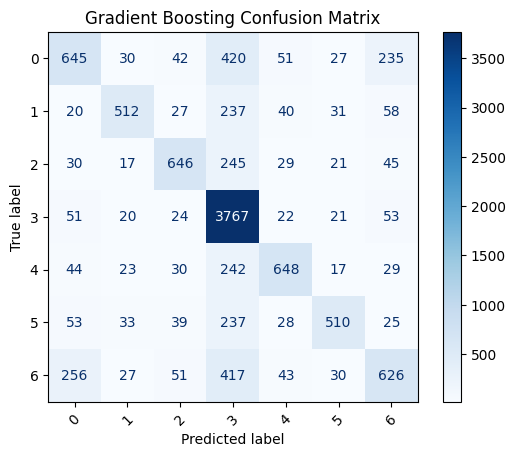

In [16]:
# Model: Gradient Boosting #
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_scaled, y_train)
gb_pred = gb_model.predict(X_val_scaled)
gb_prob = gb_model.predict_proba(X_val_scaled) if hasattr(gb_model, "predict_proba") else None

print("\nGradient Boosting Results")
print("Accuracy:", accuracy_score(y_val, gb_pred))
print("Precision:", precision_score(y_val, gb_pred, average='macro'))
print("Recall:", recall_score(y_val, gb_pred, average='macro'))
print("F1-score:", f1_score(y_val, gb_pred, average='macro'))
print(classification_report(y_val, gb_pred))

cm = confusion_matrix(y_val, gb_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues', xticks_rotation=45)
plt.title("Gradient Boosting Confusion Matrix")
plt.show()





Neural Network (MLP) Results
Accuracy: 0.6397809541488769
Precision: 0.6012800916367266
Recall: 0.602281097696587
F1-score: 0.6016559516402522
              precision    recall  f1-score   support

           0       0.49      0.49      0.49      1450
           1       0.61      0.58      0.60       925
           2       0.61      0.63      0.62      1033
           3       0.78      0.77      0.77      3958
           4       0.61      0.64      0.62      1033
           5       0.62      0.60      0.61       925
           6       0.50      0.50      0.50      1450

    accuracy                           0.64     10774
   macro avg       0.60      0.60      0.60     10774
weighted avg       0.64      0.64      0.64     10774



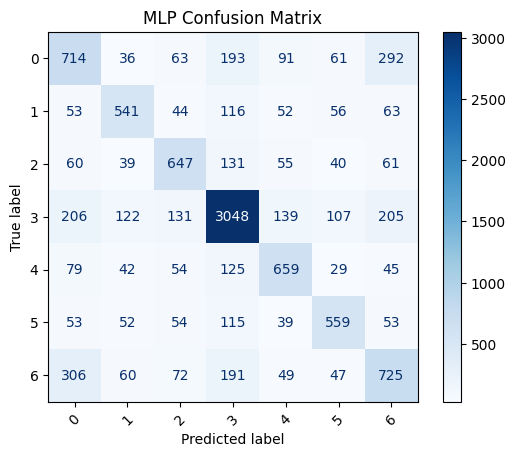

In [15]:
# Model: MLP #
mlp_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
mlp_model.fit(X_scaled, y_train)
mlp_pred = mlp_model.predict(X_val_scaled)
mlp_prob = mlp_model.predict_proba(X_val_scaled) if hasattr(mlp_model, "predict_proba") else None
print("\nNeural Network (MLP) Results")
print("Accuracy:", accuracy_score(y_val, mlp_pred))
print("Precision:", precision_score(y_val, mlp_pred, average='macro'))
print("Recall:", recall_score(y_val, mlp_pred, average='macro'))
print("F1-score:", f1_score(y_val, mlp_pred, average='macro'))
print(classification_report(y_val, mlp_pred))

cm = confusion_matrix(y_val, mlp_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues', xticks_rotation=45)
plt.title("MLP Confusion Matrix")
plt.show()



XGBoost Results
Accuracy: 0.7089289029144236
Precision: 0.7114084560778856
Recall: 0.6442377695495181
F1-score: 0.6722923156256039
              precision    recall  f1-score   support

           0       0.58      0.52      0.55      1450
           1       0.77      0.62      0.68       925
           2       0.78      0.66      0.71      1033
           3       0.73      0.92      0.82      3958
           4       0.77      0.66      0.71      1033
           5       0.77      0.62      0.68       925
           6       0.59      0.53      0.55      1450

    accuracy                           0.71     10774
   macro avg       0.71      0.64      0.67     10774
weighted avg       0.71      0.71      0.70     10774



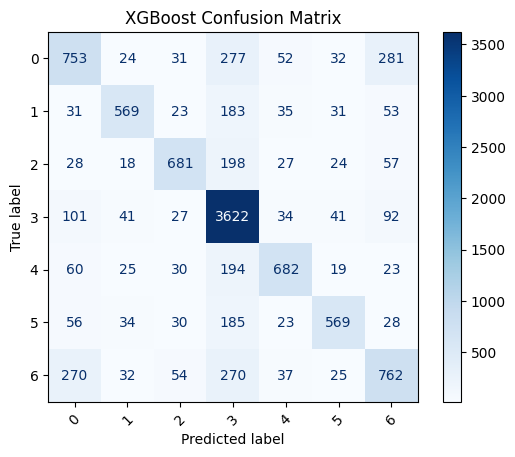

In [13]:
# Model: XGB #
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_scaled, y_train)
xgb_pred = xgb_model.predict(X_val_scaled)
xgb_prob = xgb_model.predict_proba(X_val_scaled) if hasattr(xgb_model, "predict_proba") else None

print("\nXGBoost Results")
print("Accuracy:", accuracy_score(y_val, xgb_pred))
print("Precision:", precision_score(y_val, xgb_pred, average='macro'))
print("Recall:", recall_score(y_val, xgb_pred, average='macro'))
print("F1-score:", f1_score(y_val, xgb_pred, average='macro'))
print(classification_report(y_val, xgb_pred))

cm = confusion_matrix(y_val, xgb_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues', xticks_rotation=45)
plt.title("XGBoost Confusion Matrix")
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 874
[LightGBM] [Info] Number of data points in the train set: 49993, number of used features: 109
[LightGBM] [Info] Start training from score -1.946731
[LightGBM] [Info] Start training from score -2.498217
[LightGBM] [Info] Start training from score -2.317965
[LightGBM] [Info] Start training from score -1.040977
[LightGBM] [Info] Start training from score -2.317965
[LightGBM] [Info] Start training from score -2.498217
[LightGBM] [Info] Start training from score -1.946731

LightGBM Results
Accuracy: 0.7069797661035827
Precision: 0.7160588626929689
Recall: 0.6345229457626137
F1-score: 0.6672492035659949
              precision    recall  f1-score   support

           0       0.60      0.50      0.55      1450
           1       0.78    

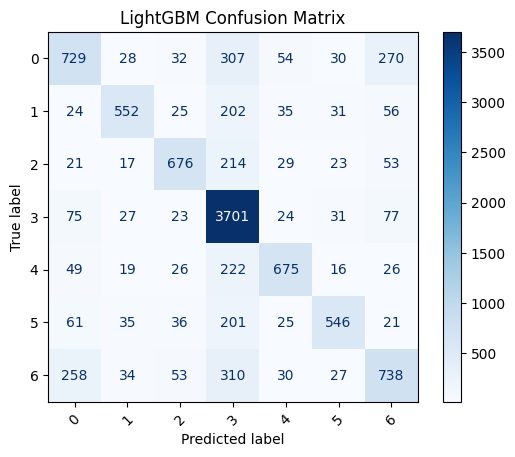

In [12]:
# Model: LGBM #
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_scaled, y_train)
lgbm_pred = lgbm_model.predict(X_val_scaled)
lgbm_prob = lgbm_model.predict_proba(X_val_scaled) if hasattr(lgbm_model, "predict_proba") else None

print("\nLightGBM Results")
print("Accuracy:", accuracy_score(y_val, lgbm_pred))
print("Precision:", precision_score(y_val, lgbm_pred, average='macro'))
print("Recall:", recall_score(y_val, lgbm_pred, average='macro'))
print("F1-score:", f1_score(y_val, lgbm_pred, average='macro'))
print(classification_report(y_val, lgbm_pred))

cm = confusion_matrix(y_val, lgbm_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues', xticks_rotation=45)
plt.title("LightGBM Confusion Matrix")
plt.show()

In [ ]:
# Save the trained model as weights
cat_model.save_model('weights.cbm')

submission_artifacts = {
    'model': cat_model,
    'feature_cols': X_train.columns.tolist(),
    'best_params': best_params
}

with open('catboost_complete.pkl', 'wb') as f:
    pickle.dump(submission_artifacts, f)
